Confidence Intervals Worksheet
Topic: Estimating Battery Performance & Reliability in Electric Vehicles
Part A – Conceptual Understanding
- Q1. Define the following terms with your own words and an EV example:
- ⦁	a. Confidence Interval (CI)
- ⦁	b. Confidence Level (CL)
- ⦁	c. Margin of Error (ME)
- Q2. Choose the correct answer (✓):
1.	 A 95% CI means:
- ⦁	☐ The sample mean is always within this range
- ⦁	☐ The true mean has a 95% probability of falling within this range
- ⦁	☐ It's about long-run coverage over repeated samples
- ⦁	☐ The standard deviation is 95%
- Q3. When should you use a t-distribution over a Z-distribution? Explain with an EV battery example. answer in detail  with visualization using python codes of all questions

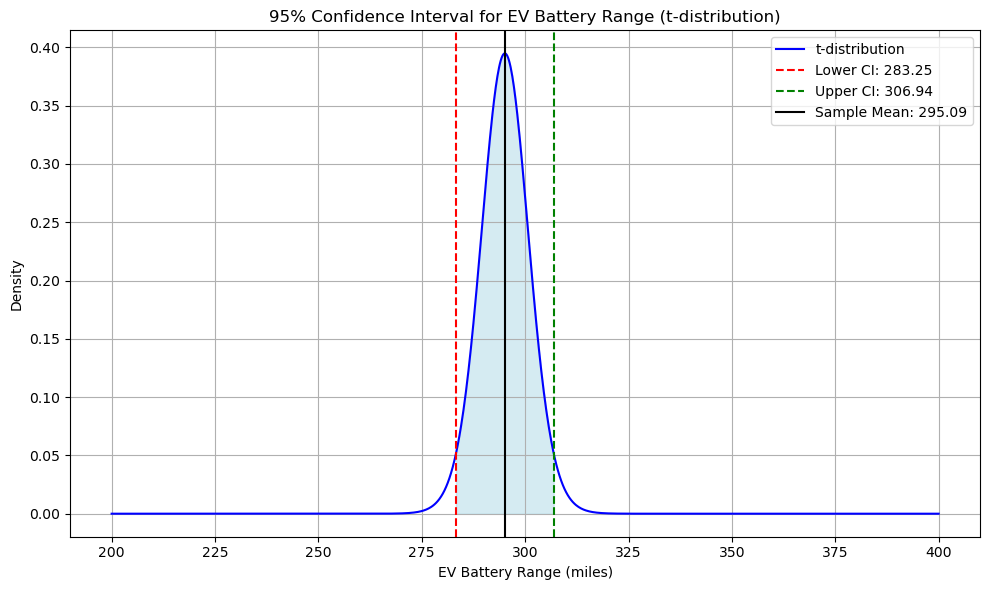

In [1]:

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Data for visualizations
np.random.seed(42)
sample_size = 25
population_mean = 300  # EV battery range in miles
population_std = 30  # Standard deviation in battery range

# Generate a sample
sample = np.random.normal(loc=population_mean, scale=population_std, size=sample_size)
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)

# Confidence Interval (95%)
confidence_level = 0.95
alpha = 1 - confidence_level
t_critical = stats.t.ppf(1 - alpha/2, df=sample_size-1)
margin_of_error = t_critical * (sample_std / np.sqrt(sample_size))
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

# Visualization for Q1 and Q3
x = np.linspace(200, 400, 1000)
t_dist = stats.t.pdf((x - sample_mean) / (sample_std / np.sqrt(sample_size)), df=sample_size-1)

# Plotting the t-distribution and confidence interval
plt.figure(figsize=(10, 6))
plt.plot(x, t_dist, label="t-distribution", color='blue')
plt.axvline(ci_lower, color='red', linestyle='--', label=f"Lower CI: {ci_lower:.2f}")
plt.axvline(ci_upper, color='green', linestyle='--', label=f"Upper CI: {ci_upper:.2f}")
plt.axvline(sample_mean, color='black', linestyle='-', label=f"Sample Mean: {sample_mean:.2f}")
plt.fill_between(x, t_dist, where=(x >= ci_lower) & (x <= ci_upper), color='lightblue', alpha=0.5)
plt.title("95% Confidence Interval for EV Battery Range (t-distribution)")
plt.xlabel("EV Battery Range (miles)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


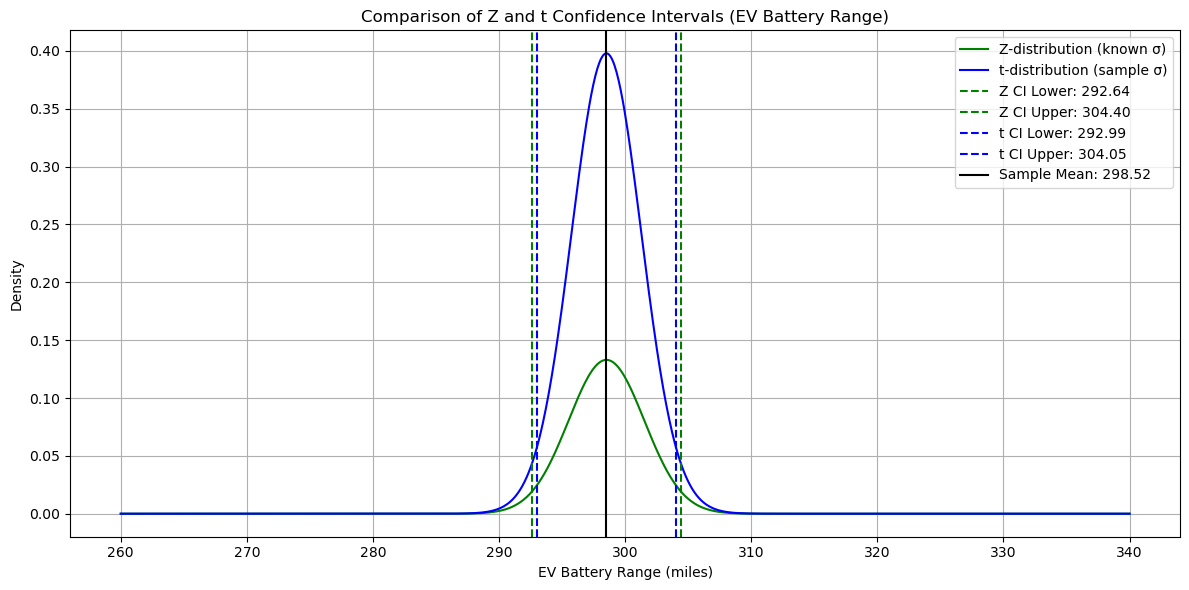

In [2]:
# New sample parameters for comparison
larger_sample_size = 100
larger_sample = np.random.normal(loc=population_mean, scale=population_std, size=larger_sample_size)
larger_sample_mean = np.mean(larger_sample)
larger_sample_std = np.std(larger_sample, ddof=1)

# Confidence Interval using Z-distribution (assuming known population std for demonstration)
z_critical = stats.norm.ppf(1 - alpha/2)
margin_of_error_z = z_critical * (population_std / np.sqrt(larger_sample_size))
ci_lower_z = larger_sample_mean - margin_of_error_z
ci_upper_z = larger_sample_mean + margin_of_error_z

# Confidence Interval using t-distribution
t_critical_large = stats.t.ppf(1 - alpha/2, df=larger_sample_size-1)
margin_of_error_t = t_critical_large * (larger_sample_std / np.sqrt(larger_sample_size))
ci_lower_t = larger_sample_mean - margin_of_error_t
ci_upper_t = larger_sample_mean + margin_of_error_t

# Visualization
x = np.linspace(260, 340, 1000)
z_dist = stats.norm.pdf(x, loc=larger_sample_mean, scale=population_std / np.sqrt(larger_sample_size))
t_dist_large = stats.t.pdf((x - larger_sample_mean) / (larger_sample_std / np.sqrt(larger_sample_size)), 
                           df=larger_sample_size-1)

plt.figure(figsize=(12, 6))
plt.plot(x, z_dist, label="Z-distribution (known σ)", color='green')
plt.plot(x, t_dist_large, label="t-distribution (sample σ)", color='blue')

# CI lines
plt.axvline(ci_lower_z, color='green', linestyle='--', label=f"Z CI Lower: {ci_lower_z:.2f}")
plt.axvline(ci_upper_z, color='green', linestyle='--', label=f"Z CI Upper: {ci_upper_z:.2f}")
plt.axvline(ci_lower_t, color='blue', linestyle='--', label=f"t CI Lower: {ci_lower_t:.2f}")
plt.axvline(ci_upper_t, color='blue', linestyle='--', label=f"t CI Upper: {ci_upper_t:.2f}")
plt.axvline(larger_sample_mean, color='black', linestyle='-', label=f"Sample Mean: {larger_sample_mean:.2f}")

plt.title("Comparison of Z and t Confidence Intervals (EV Battery Range)")
plt.xlabel("EV Battery Range (miles)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


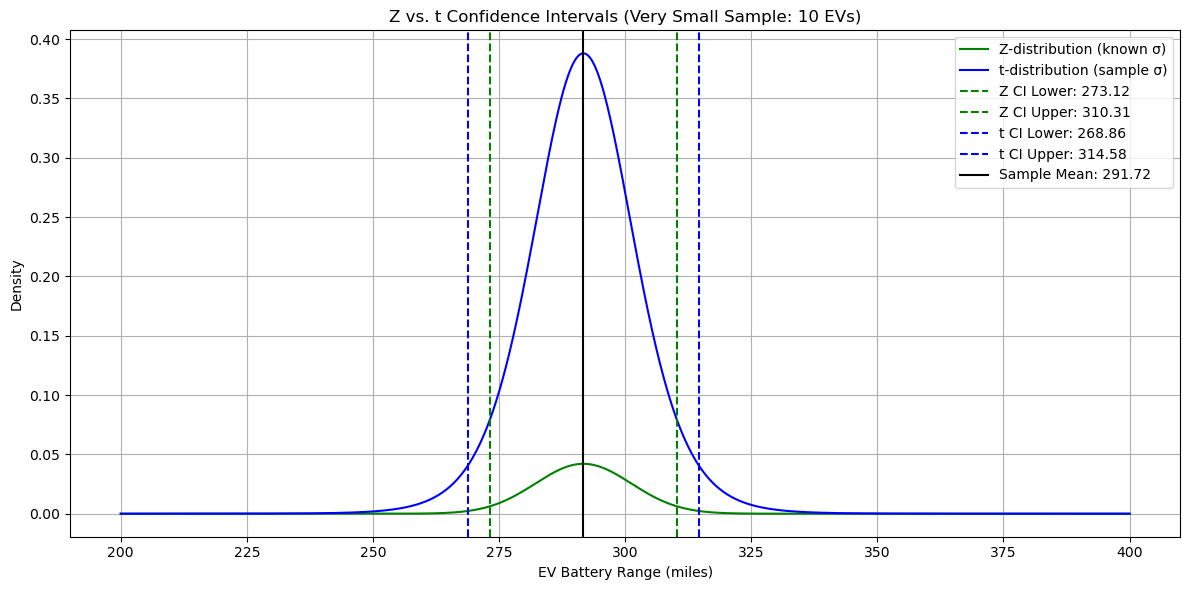

In [3]:
# Very small sample size for closer comparison
small_sample_size = 10
small_sample = np.random.normal(loc=population_mean, scale=population_std, size=small_sample_size)
small_sample_mean = np.mean(small_sample)
small_sample_std = np.std(small_sample, ddof=1)

# Z-distribution CI (again, assuming known population std)
margin_of_error_z_small = z_critical * (population_std / np.sqrt(small_sample_size))
ci_lower_z_small = small_sample_mean - margin_of_error_z_small
ci_upper_z_small = small_sample_mean + margin_of_error_z_small

# t-distribution CI
t_critical_small = stats.t.ppf(1 - alpha/2, df=small_sample_size-1)
margin_of_error_t_small = t_critical_small * (small_sample_std / np.sqrt(small_sample_size))
ci_lower_t_small = small_sample_mean - margin_of_error_t_small
ci_upper_t_small = small_sample_mean + margin_of_error_t_small

# Visualization
x = np.linspace(200, 400, 1000)
z_dist_small = stats.norm.pdf(x, loc=small_sample_mean, scale=population_std / np.sqrt(small_sample_size))
t_dist_small = stats.t.pdf((x - small_sample_mean) / (small_sample_std / np.sqrt(small_sample_size)), 
                           df=small_sample_size-1)

plt.figure(figsize=(12, 6))
plt.plot(x, z_dist_small, label="Z-distribution (known σ)", color='green')
plt.plot(x, t_dist_small, label="t-distribution (sample σ)", color='blue')

# CI lines
plt.axvline(ci_lower_z_small, color='green', linestyle='--', label=f"Z CI Lower: {ci_lower_z_small:.2f}")
plt.axvline(ci_upper_z_small, color='green', linestyle='--', label=f"Z CI Upper: {ci_upper_z_small:.2f}")
plt.axvline(ci_lower_t_small, color='blue', linestyle='--', label=f"t CI Lower: {ci_lower_t_small:.2f}")
plt.axvline(ci_upper_t_small, color='blue', linestyle='--', label=f"t CI Upper: {ci_upper_t_small:.2f}")
plt.axvline(small_sample_mean, color='black', linestyle='-', label=f"Sample Mean: {small_sample_mean:.2f}")

plt.title("Z vs. t Confidence Intervals (Very Small Sample: 10 EVs)")
plt.xlabel("EV Battery Range (miles)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Part B – Calculation-Based Tasks
Q4. Calculate the 95% CI for average EV range:
- You tested 10 electric vehicles and got the following ranges (in km):
- For example: [285, 290, 295, 270, 275, 300, 310, 280, 295, 288]
- Note: Assume population std. deviation is unknown. Use t-distribution

In [4]:
# Re-import necessary libraries after code state reset
import numpy as np
import scipy.stats as stats

# Provided sample data (EV ranges in km)
ev_ranges = [285, 290, 295, 270, 275, 300, 310, 280, 295, 288]
n = len(ev_ranges)
sample_mean = np.mean(ev_ranges)
sample_std = np.std(ev_ranges, ddof=1)

# 95% CI using t-distribution
confidence_level = 0.95
alpha = 1 - confidence_level
t_critical = stats.t.ppf(1 - alpha/2, df=n-1)
margin_of_error = t_critical * (sample_std / np.sqrt(n))
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

(sample_mean, margin_of_error, ci_lower, ci_upper)


(288.8, 8.563060879266011, 280.236939120734, 297.363060879266)

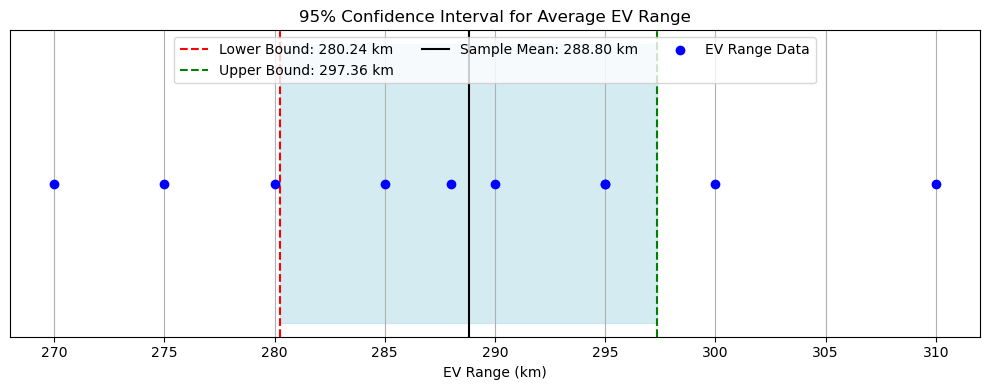

In [5]:
import matplotlib.pyplot as plt

# Plotting the confidence interval
plt.figure(figsize=(10, 4))
plt.axvline(ci_lower, color='red', linestyle='--', label=f"Lower Bound: {ci_lower:.2f} km")
plt.axvline(ci_upper, color='green', linestyle='--', label=f"Upper Bound: {ci_upper:.2f} km")
plt.axvline(sample_mean, color='black', linestyle='-', label=f"Sample Mean: {sample_mean:.2f} km")

# Plotting individual data points
plt.scatter(ev_ranges, [1]*len(ev_ranges), color='blue', zorder=5, label="EV Range Data")
plt.fill_betweenx([0.9, 1.1], ci_lower, ci_upper, color='lightblue', alpha=0.5)

plt.title("95% Confidence Interval for Average EV Range")
plt.xlabel("EV Range (km)")
plt.yticks([])
plt.legend(loc='upper center', ncol=3)
plt.grid(axis='x')
plt.tight_layout()
plt.show()


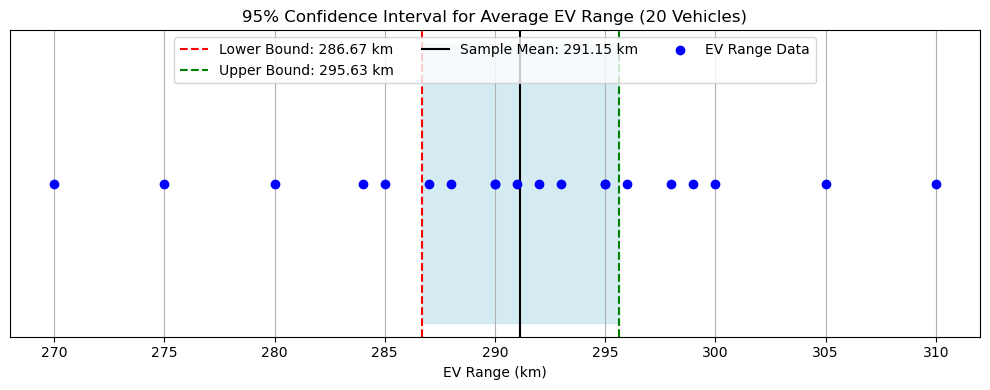

(291.15, 4.482032955200844, 286.6679670447991, 295.6320329552008)

In [6]:
# Add more EV range values to increase the sample size
extended_ev_ranges = ev_ranges + [292, 298, 305, 287, 290, 299, 284, 293, 296, 291]
n_extended = len(extended_ev_ranges)
extended_mean = np.mean(extended_ev_ranges)
extended_std = np.std(extended_ev_ranges, ddof=1)

# Recalculate the 95% CI using t-distribution
t_critical_ext = stats.t.ppf(1 - alpha/2, df=n_extended-1)
margin_of_error_ext = t_critical_ext * (extended_std / np.sqrt(n_extended))
ci_lower_ext = extended_mean - margin_of_error_ext
ci_upper_ext = extended_mean + margin_of_error_ext

# Plotting the updated confidence interval
plt.figure(figsize=(10, 4))
plt.axvline(ci_lower_ext, color='red', linestyle='--', label=f"Lower Bound: {ci_lower_ext:.2f} km")
plt.axvline(ci_upper_ext, color='green', linestyle='--', label=f"Upper Bound: {ci_upper_ext:.2f} km")
plt.axvline(extended_mean, color='black', linestyle='-', label=f"Sample Mean: {extended_mean:.2f} km")

# Plotting new data points
plt.scatter(extended_ev_ranges, [1]*len(extended_ev_ranges), color='blue', zorder=5, label="EV Range Data")
plt.fill_betweenx([0.9, 1.1], ci_lower_ext, ci_upper_ext, color='lightblue', alpha=0.5)

plt.title("95% Confidence Interval for Average EV Range (20 Vehicles)")
plt.xlabel("EV Range (km)")
plt.yticks([])
plt.legend(loc='upper center', ncol=3)
plt.grid(axis='x')
plt.tight_layout()
plt.show()

(extended_mean, margin_of_error_ext, ci_lower_ext, ci_upper_ext)


# Q5. CI for failure rate:
- Out of 150 EVs tested, 12 experienced charging station issues.
- a) Calculate the sample proportion.
- b) Construct a 95% CI for the proportion of EVs likely to face issues.


In [7]:
# Re-import libraries after kernel reset
import numpy as np
import scipy.stats as stats

# Given values
n_ev = 150          # total EVs tested
failures = 12       # EVs with charging station issues
p_hat = failures / n_ev  # sample proportion

# 95% Confidence Interval for population proportion using normal approximation
alpha = 0.05
z_critical = stats.norm.ppf(1 - alpha / 2)
margin_of_error_prop = z_critical * np.sqrt((p_hat * (1 - p_hat)) / n_ev)
ci_lower_prop = p_hat - margin_of_error_prop
ci_upper_prop = p_hat + margin_of_error_prop

(p_hat, margin_of_error_prop, ci_lower_prop, ci_upper_prop)


(0.08, 0.043415156278507755, 0.03658484372149225, 0.12341515627850776)

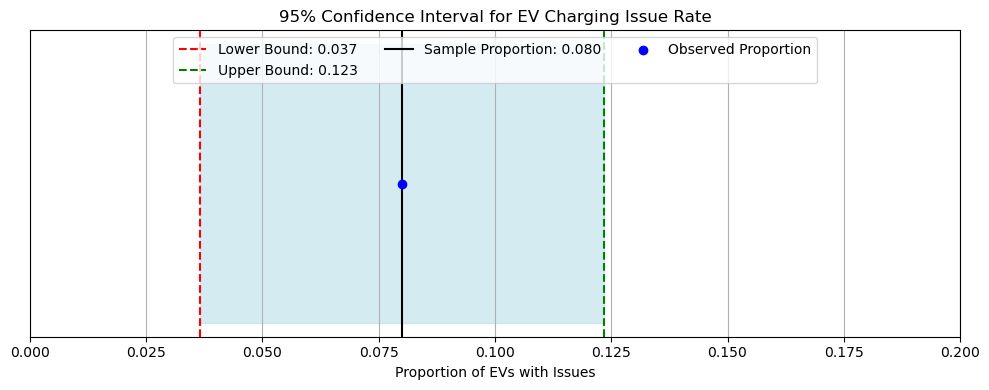

In [8]:
import matplotlib.pyplot as plt

# Plotting the confidence interval for proportion
plt.figure(figsize=(10, 4))
plt.axvline(ci_lower_prop, color='red', linestyle='--', label=f"Lower Bound: {ci_lower_prop:.3f}")
plt.axvline(ci_upper_prop, color='green', linestyle='--', label=f"Upper Bound: {ci_upper_prop:.3f}")
plt.axvline(p_hat, color='black', linestyle='-', label=f"Sample Proportion: {p_hat:.3f}")

plt.fill_betweenx([0.9, 1.1], ci_lower_prop, ci_upper_prop, color='lightblue', alpha=0.5)
plt.scatter([p_hat], [1], color='blue', zorder=5, label="Observed Proportion")

plt.title("95% Confidence Interval for EV Charging Issue Rate")
plt.xlabel("Proportion of EVs with Issues")
plt.yticks([])
plt.xlim(0, 0.2)
plt.grid(axis='x')
plt.legend(loc='upper center', ncol=3)
plt.tight_layout()
plt.show()


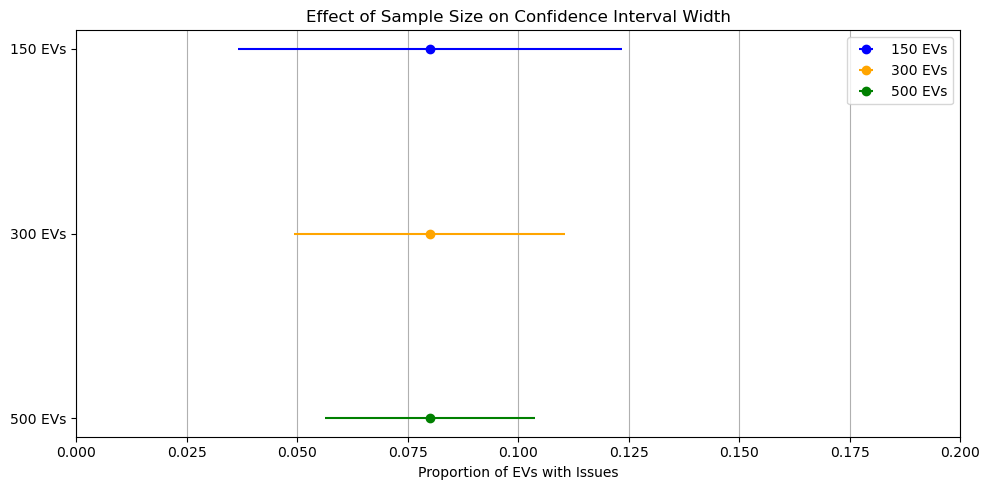

((0.04930084858919346, 0.11069915141080655),
 (0.056220539568649266, 0.10377946043135074))

In [9]:
# Simulate same issue rate with larger sample sizes (300 and 500 EVs)
n_300 = 300
failures_300 = int(p_hat * n_300)
p_hat_300 = failures_300 / n_300
margin_300 = z_critical * np.sqrt((p_hat_300 * (1 - p_hat_300)) / n_300)
ci_300 = (p_hat_300 - margin_300, p_hat_300 + margin_300)

n_500 = 500
failures_500 = int(p_hat * n_500)
p_hat_500 = failures_500 / n_500
margin_500 = z_critical * np.sqrt((p_hat_500 * (1 - p_hat_500)) / n_500)
ci_500 = (p_hat_500 - margin_500, p_hat_500 + margin_500)

# Plot all three intervals
plt.figure(figsize=(10, 5))

# Original: 150 EVs
plt.errorbar(p_hat, 3, xerr=margin_of_error_prop, fmt='o', color='blue', label='150 EVs')
# Simulated: 300 EVs
plt.errorbar(p_hat_300, 2, xerr=margin_300, fmt='o', color='orange', label='300 EVs')
# Simulated: 500 EVs
plt.errorbar(p_hat_500, 1, xerr=margin_500, fmt='o', color='green', label='500 EVs')

plt.yticks([1, 2, 3], ['500 EVs', '300 EVs', '150 EVs'])
plt.xlabel("Proportion of EVs with Issues")
plt.title("Effect of Sample Size on Confidence Interval Width")
plt.grid(True, axis='x')
plt.xlim(0, 0.2)
plt.legend()
plt.tight_layout()
plt.show()

(ci_300, ci_500)


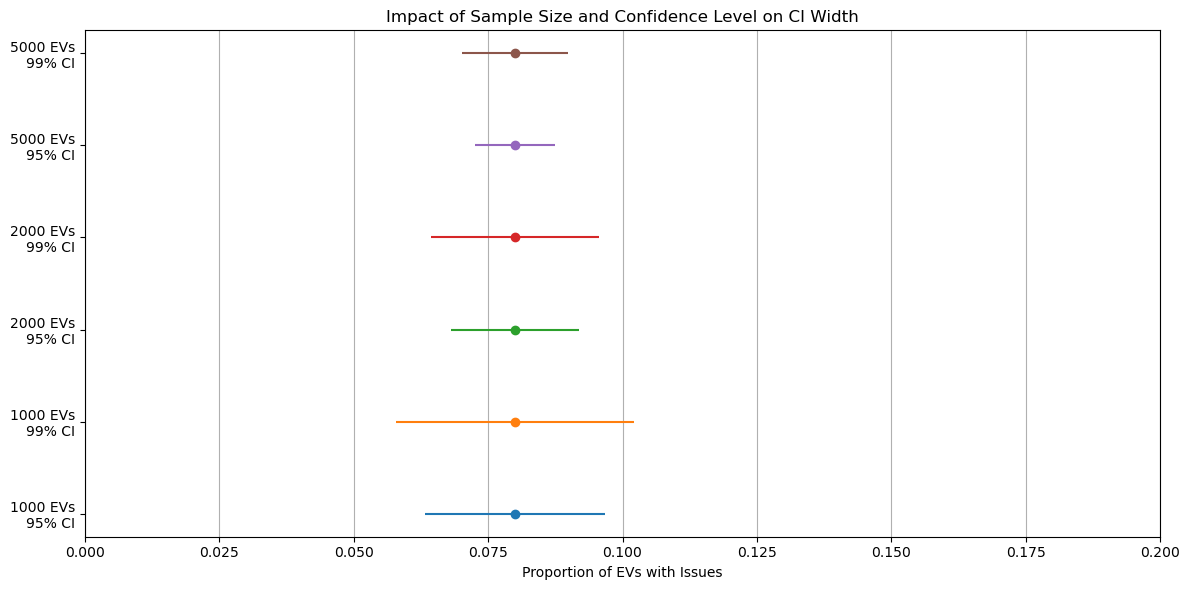

[(1000,
  0.95,
  0.08,
  0.06318538227603471,
  0.0968146177239653,
  0.01681461772396529),
 (1000,
  0.99,
  0.08,
  0.05790184646095603,
  0.10209815353904397,
  0.022098153539043968),
 (2000,
  0.95,
  0.08,
  0.06811026978432463,
  0.09188973021567537,
  0.011889730215675366),
 (2000,
  0.99,
  0.08,
  0.06437424578084051,
  0.09562575421915949,
  0.01562575421915949),
 (5000,
  0.95,
  0.08,
  0.07248027435070817,
  0.08751972564929184,
  0.007519725649291836),
 (5000,
  0.99,
  0.08,
  0.07011740530189403,
  0.08988259469810597,
  0.009882594698105972)]

In [10]:
# Try larger sample sizes and a comparison of 95% vs. 99% confidence levels
sample_sizes = [1000, 2000, 5000]
conf_levels = [0.95, 0.99]

results = []

# Loop over sample sizes and confidence levels
for size in sample_sizes:
    failures = int(p_hat * size)
    p = failures / size
    for cl in conf_levels:
        z = stats.norm.ppf(1 - (1 - cl) / 2)
        me = z * np.sqrt((p * (1 - p)) / size)
        results.append((size, cl, p, p - me, p + me, me))

# Plotting the intervals
plt.figure(figsize=(12, 6))
y_labels = []
y_pos = []

for i, (size, cl, p, low, high, me) in enumerate(results):
    plt.errorbar(p, i, xerr=me, fmt='o', label=f'n={size}, CL={int(cl*100)}%')
    y_labels.append(f"{size} EVs\n{int(cl*100)}% CI")
    y_pos.append(i)

plt.yticks(y_pos, y_labels)
plt.xlabel("Proportion of EVs with Issues")
plt.title("Impact of Sample Size and Confidence Level on CI Width")
plt.grid(axis='x')
plt.xlim(0, 0.2)
plt.tight_layout()
plt.show()

results


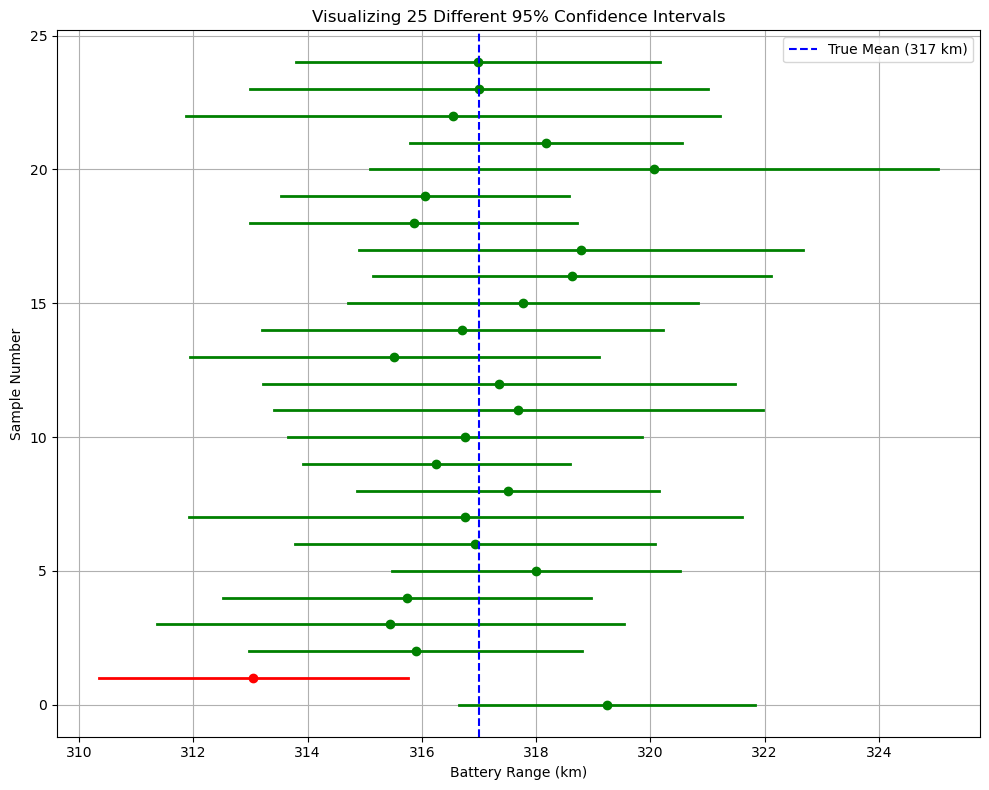

In [11]:
# Re-run after state reset
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t

# Set seed for reproducibility
np.random.seed(42)

# True population mean (unknown to us in real life)
true_mean = 317

# Simulate 25 samples of 10 battery ranges each, with some randomness
sample_size = 10
num_samples = 25
simulated_means = np.random.normal(loc=true_mean, scale=5, size=(num_samples, sample_size))
sample_means = simulated_means.mean(axis=1)
sample_stds = simulated_means.std(axis=1, ddof=1)

# Critical t value for 95% CI with df = 9
t_critical = t.ppf(0.975, df=sample_size - 1)

# Compute CIs
margin_errors = t_critical * (sample_stds / np.sqrt(sample_size))
lower_bounds = sample_means - margin_errors
upper_bounds = sample_means + margin_errors

# Plot
plt.figure(figsize=(10, 8))

for i in range(num_samples):
    color = 'green' if lower_bounds[i] <= true_mean <= upper_bounds[i] else 'red'
    plt.plot([lower_bounds[i], upper_bounds[i]], [i, i], color=color, lw=2)
    plt.plot(sample_means[i], i, 'o', color=color)

plt.axvline(true_mean, color='blue', linestyle='--', label='True Mean (317 km)')
plt.title('Visualizing 25 Different 95% Confidence Intervals')
plt.xlabel('Battery Range (km)')
plt.ylabel('Sample Number')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


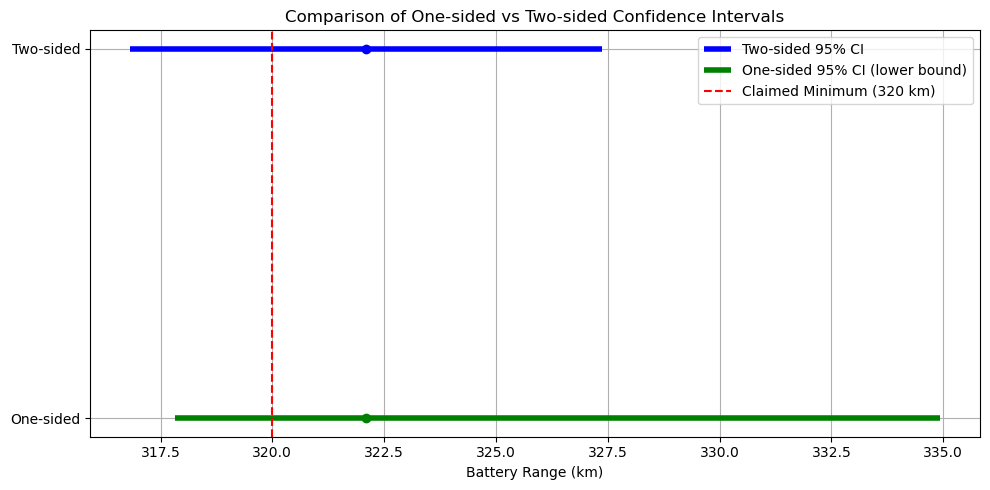

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t

# Sample data (simulated)
sample_data = np.array([310, 315, 318, 319, 320, 322, 325, 327, 330, 335])
sample_mean = np.mean(sample_data)
sample_std = np.std(sample_data, ddof=1)
n = len(sample_data)

# t critical values
alpha_two_sided = 0.05
alpha_one_sided = 0.05

t_critical_two_sided = t.ppf(1 - alpha_two_sided / 2, df=n-1)
t_critical_one_sided = t.ppf(1 - alpha_one_sided, df=n-1)

# Margins of error
moe_two_sided = t_critical_two_sided * (sample_std / np.sqrt(n))
moe_one_sided = t_critical_one_sided * (sample_std / np.sqrt(n))

# Confidence intervals
ci_two_sided = (sample_mean - moe_two_sided, sample_mean + moe_two_sided)
ci_one_sided = (sample_mean - moe_one_sided, np.inf)

# Plot
plt.figure(figsize=(10, 5))

# Two-sided CI
plt.hlines(1, ci_two_sided[0], ci_two_sided[1], colors='blue', lw=4, label='Two-sided 95% CI')
plt.plot(sample_mean, 1, 'o', color='blue')

# One-sided CI (lower bound only)
plt.hlines(0.5, ci_one_sided[0], sample_mean + 3*moe_one_sided, colors='green', lw=4, label='One-sided 95% CI (lower bound)')
plt.plot(sample_mean, 0.5, 'o', color='green')

# Reference line for the claimed minimum
claimed_range = 320
plt.axvline(claimed_range, color='red', linestyle='--', label='Claimed Minimum (320 km)')

plt.yticks([0.5, 1], ['One-sided', 'Two-sided'])
plt.xlabel('Battery Range (km)')
plt.title('Comparison of One-sided vs Two-sided Confidence Intervals')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


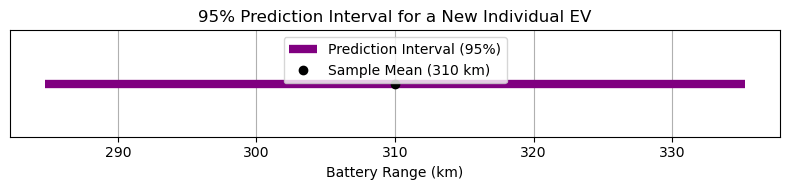

(284.7427383044383, 335.2572616955617)

In [15]:
import matplotlib.pyplot as plt
from scipy.stats import t
import numpy as np

# Given values
x_bar = 310
s = 12
n = 25
df = n - 1
confidence = 0.95

# t critical value for 95% prediction interval
t_critical = t.ppf(1 - (1 - confidence) / 2, df)

# Prediction interval formula
margin_of_error = t_critical * s * np.sqrt(1 + 1/n)
lower_bound = x_bar - margin_of_error
upper_bound = x_bar + margin_of_error

# Plotting the prediction interval
plt.figure(figsize=(8, 2))
plt.hlines(1, lower_bound, upper_bound, colors='purple', lw=6, label='Prediction Interval (95%)')
plt.plot(x_bar, 1, 'o', color='black', label='Sample Mean (310 km)')

plt.title('95% Prediction Interval for a New Individual EV')
plt.xlabel('Battery Range (km)')
plt.yticks([])
plt.grid(True)
plt.legend(loc='upper center')
plt.tight_layout()
plt.show()

(lower_bound, upper_bound)


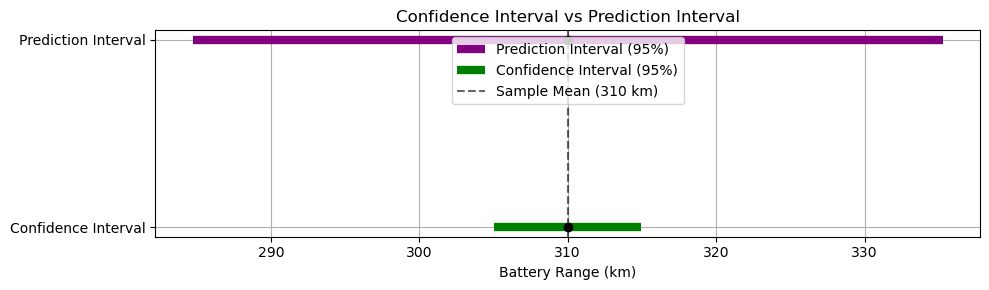

In [16]:

# Confidence Interval for the mean
ci_margin_of_error = t_critical * s / np.sqrt(n)
ci_lower = x_bar - ci_margin_of_error
ci_upper = x_bar + ci_margin_of_error

# Plotting both intervals
plt.figure(figsize=(10, 3))

# Prediction interval (wider)
plt.hlines(1, lower_bound, upper_bound, colors='purple', lw=6, label='Prediction Interval (95%)')
plt.plot(x_bar, 1, 'o', color='black')

# Confidence interval (narrower)
plt.hlines(0.5, ci_lower, ci_upper, colors='green', lw=6, label='Confidence Interval (95%)')
plt.plot(x_bar, 0.5, 'o', color='black')

plt.axvline(x_bar, color='black', linestyle='--', alpha=0.6, label='Sample Mean (310 km)')
plt.title('Confidence Interval vs Prediction Interval')
plt.xlabel('Battery Range (km)')
plt.yticks([0.5, 1], ['Confidence Interval', 'Prediction Interval'])
plt.grid(True)
plt.legend(loc='upper center')
plt.tight_layout()
plt.show()


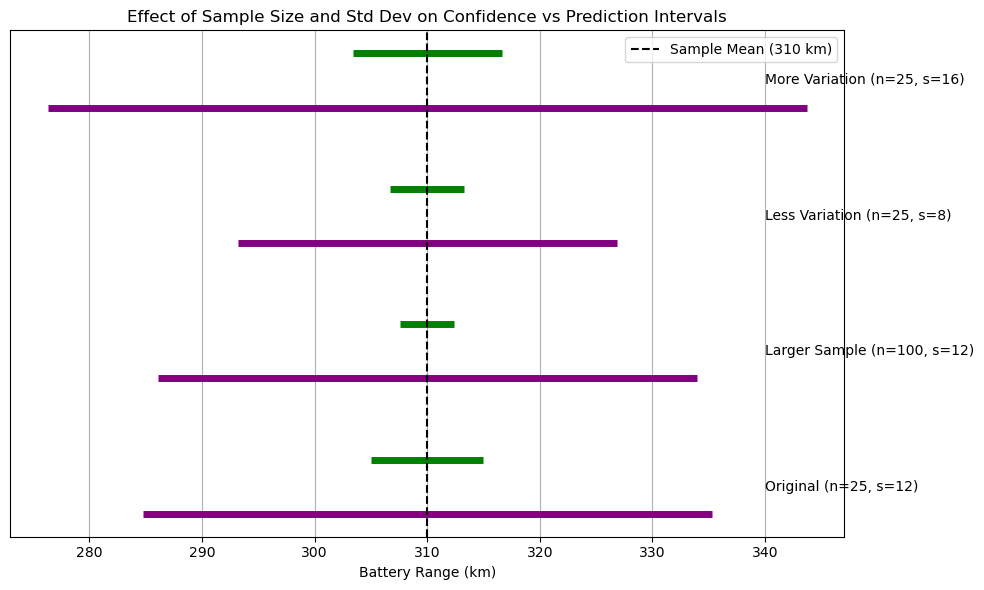

In [17]:

# Function to calculate and return intervals for given sample size and std deviation
def compute_intervals(x_bar, s, n, confidence=0.95):
    df = n - 1
    t_critical = t.ppf(1 - (1 - confidence) / 2, df)
    
    # CI
    ci_margin = t_critical * s / np.sqrt(n)
    ci = (x_bar - ci_margin, x_bar + ci_margin)
    
    # PI
    pi_margin = t_critical * s * np.sqrt(1 + 1/n)
    pi = (x_bar - pi_margin, x_bar + pi_margin)
    
    return ci, pi

# Sample scenarios
scenarios = [
    {"label": "Original (n=25, s=12)", "n": 25, "s": 12},
    {"label": "Larger Sample (n=100, s=12)", "n": 100, "s": 12},
    {"label": "Less Variation (n=25, s=8)", "n": 25, "s": 8},
    {"label": "More Variation (n=25, s=16)", "n": 25, "s": 16},
]

# Plot setup
plt.figure(figsize=(10, 6))

for i, scenario in enumerate(scenarios):
    ci, pi = compute_intervals(x_bar, scenario["s"], scenario["n"])
    
    # Plot confidence interval
    plt.hlines(i + 0.2, ci[0], ci[1], color='green', lw=5)
    # Plot prediction interval
    plt.hlines(i - 0.2, pi[0], pi[1], color='purple', lw=5)
    # Label
    plt.text(x_bar + 30, i, scenario["label"], va='center', fontsize=10)

# Mean line
plt.axvline(x_bar, linestyle='--', color='black', label='Sample Mean (310 km)')
plt.title('Effect of Sample Size and Std Dev on Confidence vs Prediction Intervals')
plt.xlabel('Battery Range (km)')
plt.yticks([])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [18]:
# Re-import necessary libraries due to code execution reset
from scipy.stats import t
import matplotlib.pyplot as plt
import numpy as np

# Given data
mean_A, std_A, n_A = 295, 10, 20
mean_B, std_B, n_B = 310, 8, 20
confidence = 0.95
df_A = n_A - 1
df_B = n_B - 1

# t-critical values
t_crit_A = t.ppf(1 - (1 - confidence) / 2, df_A)
t_crit_B = t.ppf(1 - (1 - confidence) / 2, df_B)

# Confidence intervals
margin_A = t_crit_A * std_A / (n_A ** 0.5)
ci_A = (mean_A - margin_A, mean_A + margin_A)

margin_B = t_crit_B * std_B / (n_B ** 0.5)
ci_B = (mean_B - margin_B, mean_B + margin_B)

ci_A, ci_B


((290.3198559358009, 299.6801440641991),
 (306.2558847486407, 313.7441152513593))

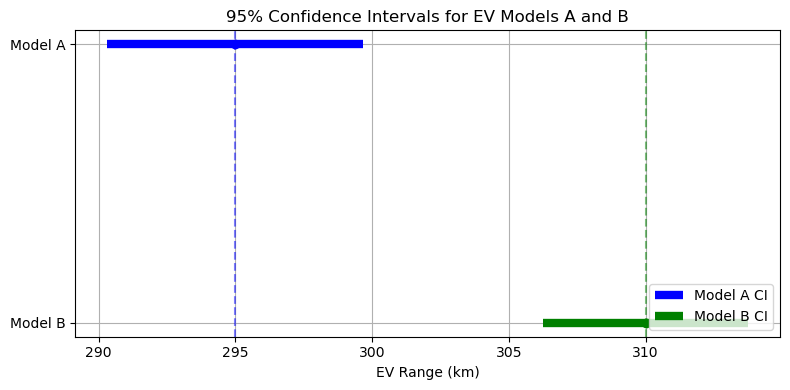

In [19]:
# Plotting side-by-side CIs for Model A and B
plt.figure(figsize=(8, 4))

# Confidence Intervals
plt.hlines(1, ci_A[0], ci_A[1], color='blue', lw=6, label='Model A CI')
plt.plot(mean_A, 1, 'o', color='blue')

plt.hlines(0.5, ci_B[0], ci_B[1], color='green', lw=6, label='Model B CI')
plt.plot(mean_B, 0.5, 'o', color='green')

# Mean line references
plt.axvline(mean_A, color='blue', linestyle='--', alpha=0.5)
plt.axvline(mean_B, color='green', linestyle='--', alpha=0.5)

# Labels and grid
plt.yticks([0.5, 1], ['Model B', 'Model A'])
plt.xlabel("EV Range (km)")
plt.title("95% Confidence Intervals for EV Models A and B")
plt.grid(True)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


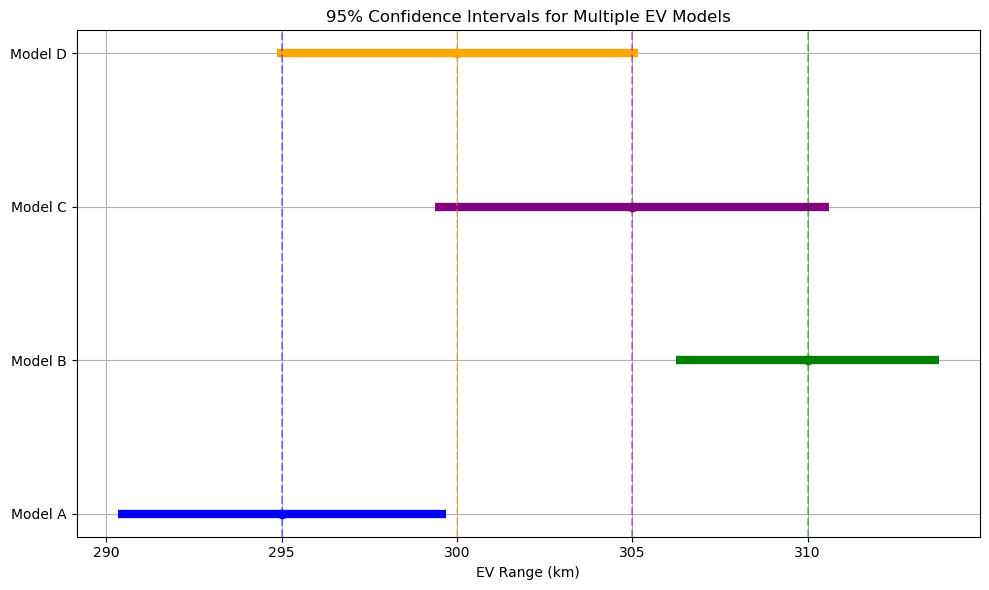

In [20]:
# Let's add two more models: Model C and D with their stats
models = {
    'Model A': {'mean': 295, 'std': 10, 'n': 20, 'color': 'blue'},
    'Model B': {'mean': 310, 'std': 8, 'n': 20, 'color': 'green'},
    'Model C': {'mean': 305, 'std': 12, 'n': 20, 'color': 'purple'},
    'Model D': {'mean': 300, 'std': 11, 'n': 20, 'color': 'orange'}
}

# Compute confidence intervals
cis = {}
for model, data in models.items():
    mean = data['mean']
    std = data['std']
    n = data['n']
    df = n - 1
    t_crit = t.ppf(1 - 0.025, df)
    margin = t_crit * std / (n ** 0.5)
    cis[model] = (mean - margin, mean + margin)

# Plotting
plt.figure(figsize=(10, 6))
yticks = []
for i, (model, ci) in enumerate(cis.items(), 1):
    color = models[model]['color']
    mean = models[model]['mean']
    plt.hlines(i, ci[0], ci[1], color=color, lw=6, label=f"{model} CI")
    plt.plot(mean, i, 'o', color=color)
    yticks.append((i, model))

# Add mean lines
for model in models:
    plt.axvline(models[model]['mean'], color=models[model]['color'], linestyle='--', alpha=0.4)

# Customize plot
plt.yticks([y[0] for y in yticks], [y[1] for y in yticks])
plt.xlabel("EV Range (km)")
plt.title("95% Confidence Intervals for Multiple EV Models")
plt.grid(True)
plt.tight_layout()
plt.show()
